In [1]:
import numpy as np
import spikeinterface.extractors as se

local_path = "../data/raw/mearec_test_10s.h5"
recording, sorting_true = se.read_mearec(local_path)
fs = recording.get_sampling_frequency()

valid_spike_times = np.load("../data/raw/valid_spike_times.npy")
cluster_labels = np.load("../data/raw/cluster_labels.npy")

In [2]:
tolerance_samples = int(0.001 * fs)  # 1ms tolerance

true_labels_for_detected = []
for t in valid_spike_times:
    matched_unit = None
    for unit_id in sorting_true.unit_ids:
        true_spike_train = sorting_true.get_unit_spike_train(unit_id)
        if np.any(np.abs(true_spike_train - t) <= tolerance_samples):
            matched_unit = unit_id
            break
    true_labels_for_detected.append(matched_unit)

true_labels_for_detected = np.array(true_labels_for_detected)

matched_mask = true_labels_for_detected != None
print(f"Detection accuracy: {matched_mask.sum()} / {len(valid_spike_times)} detected spikes matched a true spike ({100*matched_mask.sum()/len(valid_spike_times):.1f}%)")

total_true_spikes = sum(len(sorting_true.get_unit_spike_train(u)) for u in sorting_true.unit_ids)
print(f"Recall: found {matched_mask.sum()} / {total_true_spikes} total true spikes ({100*matched_mask.sum()/total_true_spikes:.1f}%)")

Detection accuracy: 181 / 187 detected spikes matched a true spike (96.8%)
Recall: found 181 / 747 total true spikes (24.2%)


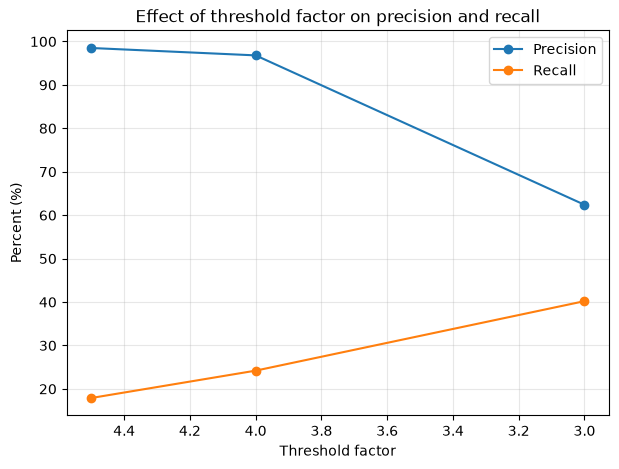

In [6]:
import matplotlib.pyplot as plt

thresholds = [4.5, 4.0, 3.0]
precision = [98.5, 96.8, 62.4]
recall = [17.9, 24.2, 40.2]

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision, marker='o', label='Precision')
plt.plot(thresholds, recall, marker='o', label='Recall')
plt.xlabel("Threshold factor")
plt.ylabel("Percent (%)")
plt.title("Effect of threshold factor on precision and recall")
plt.gca().invert_xaxis()  # so lower threshold (more sensitive) reads left-to-right
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../figures/precision+recall.png")
plt.show()